RITHESH P 24BAD098

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aleemaparakatta/cats-and-dogs-mini-dataset")

print("Path to dataset files:", path)
import os

print("Dataset path:", path)
print("Files/Folders:")

for item in os.listdir(path):
    print(item)

for root, dirs, files in os.walk(path):
    print(root, "->", len(files), "files")




100%|██████████| 21.9M/21.9M [00:00<00:00, 40.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aleemaparakatta/cats-and-dogs-mini-dataset/versions/1
Dataset path: /root/.cache/kagglehub/datasets/aleemaparakatta/cats-and-dogs-mini-dataset/versions/1
Files/Folders:
dogs_set
cats_set
/root/.cache/kagglehub/datasets/aleemaparakatta/cats-and-dogs-mini-dataset/versions/1 -> 0 files
/root/.cache/kagglehub/datasets/aleemaparakatta/cats-and-dogs-mini-dataset/versions/1/dogs_set -> 500 files
/root/.cache/kagglehub/datasets/aleemaparakatta/cats-and-dogs-mini-dataset/versions/1/cats_set -> 500 files


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil
import random

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
cat_dir = os.path.join(path, "cats_set")
dog_dir = os.path.join(path, "dogs_set")

print("Cats:", len(os.listdir(cat_dir)))
print("Dogs:", len(os.listdir(dog_dir)))
base_dir = "/content/cats_dogs_split"

for split in ["train", "validation", "test"]:
    for category in ["cats", "dogs"]:
        os.makedirs(
            os.path.join(base_dir, split, category),
            exist_ok=True
        )

def split_images(source_dir, category):
    images = [
        f for f in os.listdir(source_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    random.shuffle(images)

    total = len(images)

    train_end = int(0.70 * total)
    val_end = int(0.85 * total)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    for image in train_images:
        shutil.copy(
            os.path.join(source_dir, image),
            os.path.join(base_dir, "train", category, image)
        )

    for image in val_images:
        shutil.copy(
            os.path.join(source_dir, image),
            os.path.join(base_dir, "validation", category, image)
        )

    for image in test_images:
        shutil.copy(
            os.path.join(source_dir, image),
            os.path.join(base_dir, "test", category, image)
        )

    print(category)
    print("Train:", len(train_images))
    print("Validation:", len(val_images))
    print("Test:", len(test_images))

Cats: 500
Dogs: 500


In [3]:
split_images(cat_dir, "cats")
split_images(dog_dir, "dogs")

cats
Train: 350
Validation: 75
Test: 75
dogs
Train: 350
Validation: 75
Test: 75


In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
# data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)
train_data = train_datagen.flow_from_directory(
    os.path.join(base_dir, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)
validation_data = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, "validation"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)
test_data = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 700 images belonging to 2 classes.
Found 150 images belonging to 2 classes.
Found 150 images belonging to 2 classes.


{'cats': 0, 'dogs': 1}


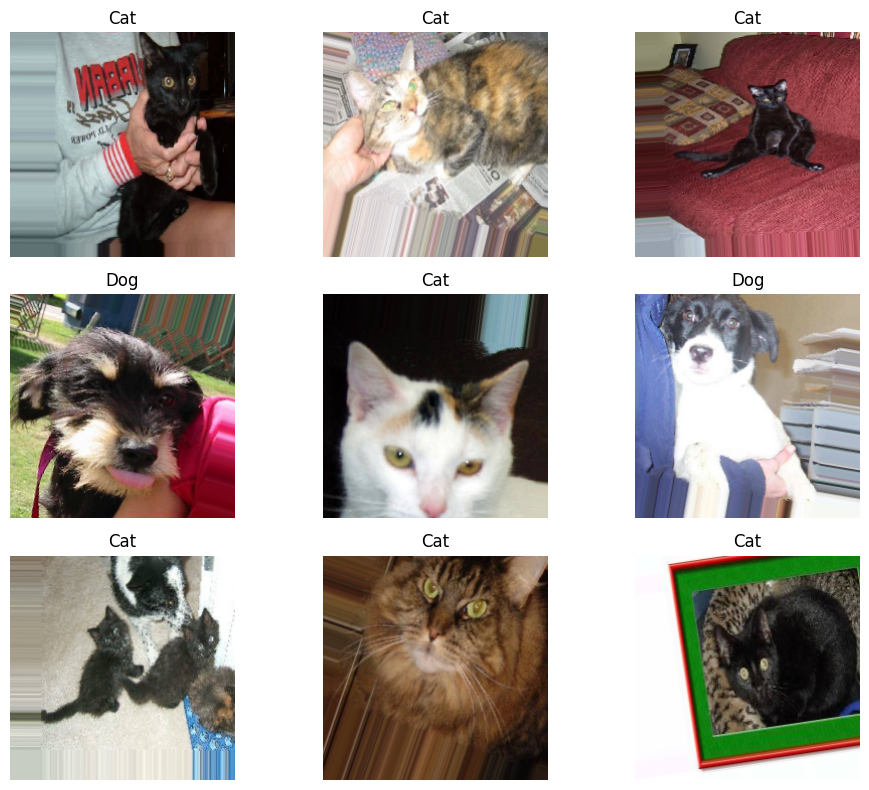

In [5]:
print(train_data.class_indices)
images, labels = next(train_data)

plt.figure(figsize=(10, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title("Dog" if labels[i] == 1 else "Cat")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# loading the ResNet50 model
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [7]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

In [8]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 23,796,993 (90.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [9]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=5
)

Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 779s 33s/step - accuracy: 0.8014 - loss: 0.5619 - val_accuracy: 0.5000 - val_loss: 10955.2852
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 716s 33s/step - accuracy: 0.7271 - loss: 0.6513 - val_accuracy: 0.5000 - val_loss: 14.9837
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 719s 32s/step - accuracy: 0.7600 - loss: 0.6183 - val_accuracy: 0.5000 - val_loss: 2631.4438
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 699s 32s/step - accuracy: 0.7714 - loss: 0.5540 - val_accuracy: 0.5000 - val_loss: 826.6912
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 686s 31s/step - accuracy: 0.8200 - loss: 0.4362 - val_accuracy: 0.5000 - val_loss: 14.5788


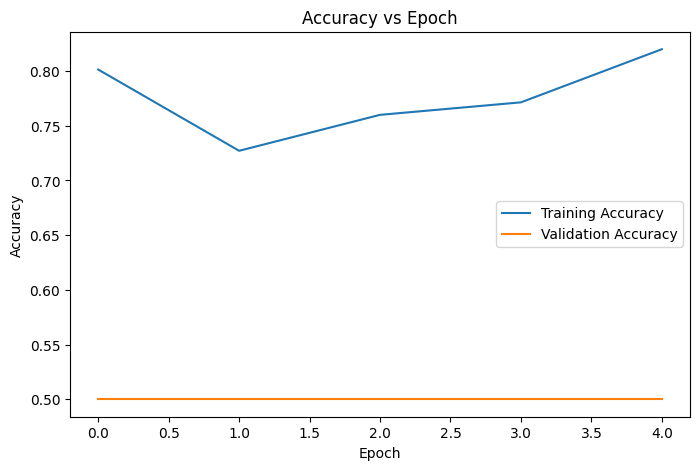

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.show()

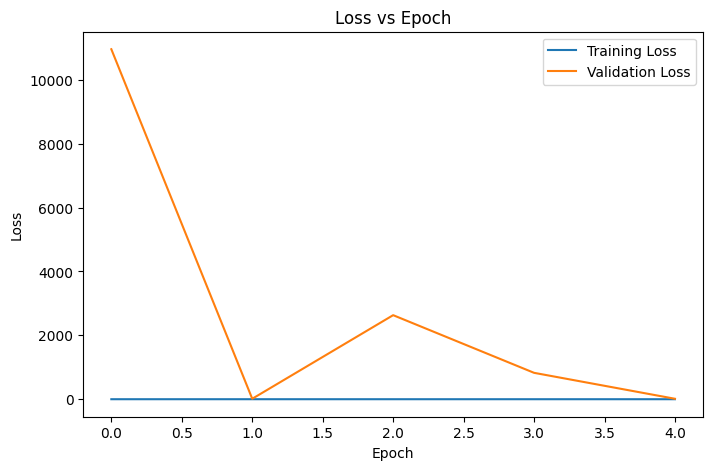

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.show()

In [12]:
test_loss, test_accuracy = model.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 29s 5s/step - accuracy: 0.5000 - loss: 14.4559
Test Loss: 14.455948829650879
Test Accuracy: 0.5


In [13]:
!pip install -q transformers

In [3]:
from transformers import pipeline
from PIL import Image
pipe = pipeline("image-classification", model="microsoft/resnet-50")
image="/content/cats_dogs_split/test/cats/cat.4008.jpg"

classifier = pipeline(
    "zero-shot-image-classification",
    model="openai/clip-vit-base-patch32"
)
from google.colab import files

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

image = Image.open(image_path)

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

Saving [000612].jpg to [000612].jpg


In [4]:
predictions = classifier(
    image,
    candidate_labels=["cat", "dog"]
)

print(predictions)

[{'score': 0.66754150390625, 'label': 'dog'}, {'score': 0.3324585556983948, 'label': 'cat'}]


In [8]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Ensure the model is defined and compiled
if 'model' not in locals() or not isinstance(model, tf.keras.Model):
    # loading the ResNet50 model
    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    print("Model re-defined and compiled due to missing definition.")

# Hugging Face prediction
hf_prediction = predictions[0]["label"]

# ResNet-50 prediction
img = image.resize((224, 224))
img_array = np.array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

resnet_score = model.predict(img_array, verbose=0)[0][0]

if resnet_score >= 0.5:
    resnet_prediction = "dog"
    resnet_confidence = resnet_score
else:
    resnet_prediction = "cat"
    resnet_confidence = 1 - resnet_score

print("Hugging Face Prediction :", hf_prediction.upper())
print("Hugging Face Confidence :", round(predictions[0]["score"] * 100, 2), "%")

print()

print("ResNet-50 Prediction     :", resnet_prediction.upper())
print("ResNet-50 Confidence     :", round(resnet_confidence * 100, 2), "%")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Model re-defined and compiled due to missing definition.
Hugging Face Prediction : DOG
Hugging Face Confidence : 66.75 %

ResNet-50 Prediction     : DOG
ResNet-50 Confidence     : 60.48 %


In [9]:
import pandas as pd
import numpy as np
# 'predictions' and 'image' are assumed to be defined from previous cells

# Hugging Face prediction
hf_prediction = predictions[0]["label"]

# ResNet-50 prediction
# 'image' is a PIL Image object from Image.open in cell 18-OBmHQ0on1
img = image.resize((224, 224))
img_array = np.array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# 'model' is assumed to be defined from previous cells (dLAf8srl0T8B)
resnet_score = model.predict(img_array, verbose=0)[0][0]

if resnet_score >= 0.5:
    resnet_prediction = "dog"
    resnet_confidence = resnet_score
else:
    resnet_prediction = "cat"
    resnet_confidence = 1 - resnet_score

comparison = pd.DataFrame({
    "Model": ["ResNet-50", "Hugging Face CLIP"],
    "Prediction": [
        resnet_prediction.upper(),
        hf_prediction.upper()
    ],
    "Confidence": [
        f"{resnet_confidence * 100:.2f}%",
        f"{predictions[0]['score'] * 100:.2f}%"
    ]
})

display(comparison)

,Model,Prediction,Confidence
0,ResNet-50,DOG,60.48%
1,Hugging Face CLIP,DOG,66.75%
